# L4b Advanced: Uncertainty in the Fitted Mean Growth Rate

How much price history do we need to estimate the mean growth rate precisely, and can more frequent observations help?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Quantify regression uncertainty:** Derive the standard error of the fitted mean growth rate under the GBM assumptions and check the result by simulating log-price paths and fitting a line to each path.
> * **Examine the role of the observation period:** Compare how the observation period and sampling frequency affect mean-growth and volatility precision, and calculate the observation period needed for a chosen confidence-interval half-width.
> * **Examine uncertainty in target probabilities:** Use the fitted parameters and their estimated uncertainty to compare how mean growth and volatility affect the probability of exceeding a target scaled NPV at the scheduled sale time.

In this example, we use a constant-parameter geometric Brownian motion (GBM) model to compare uncertainty in mean growth and volatility and examine its effect on target probabilities.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## Task 1: Quantify Uncertainty in the Regression Slope

In this task, we calculate the uncertainty in the mean growth rate estimated by fitting a line to log prices. We use the same least-squares estimator as the [parameter example](../../CHEME-5660-L4b-Example-Parameters-SAGBM-Fall-2026.ipynb), then account for the Brownian errors when calculating its standard error.

### Recall the regression model

Suppose we observe $N+1$ prices at times $t_j=j\Delta t$, covering $T_{\text{span}}=N\Delta t$ years. From the [L4b lecture](../../CHEME-5660-L4b-Lecture-SingleAsset-GeometricBrownianMotion-TradeRule-Fall-2026.ipynb), the log price satisfies:

$$
\ln(S_{t_j})=\ln(S_0)+\mu_g t_j+\sigma W(t_j),
\qquad j=0,1,\ldots,N.
$$

Here, $\mu_g=\mu-\sigma^2/2$ is the mean growth rate, in $\mathrm{yr}^{-1}$, and $\sigma>0$ is the volatility, in $\mathrm{yr}^{-1/2}$. Both parameters are constant over the observation period. We treat the initial price as fixed and assume the prices are observed without measurement error.

The expected log price is a line with intercept $\ln(S_0)$ and slope $\mu_g$. As in the parameter example, let $\mathbf y$ contain the observed log prices, and let $\hat{\mathbf X}$ contain a column of ones and a column of observation times. Then:

$$
\mathbf y=\hat{\mathbf X}\boldsymbol{\theta}+\epsilon,
\qquad
\boldsymbol{\theta}=\begin{bmatrix}\ln(S_0)\\\mu_g\end{bmatrix},
\qquad
\epsilon_j=\sigma W(t_j).
$$

The design matrix has dimensions $(N+1)\times2$. Fitting the intercept and slope by least squares gives:

$$
\hat{\boldsymbol{\theta}}
=(\hat{\mathbf X}^{\top}\hat{\mathbf X})^{-1}
\hat{\mathbf X}^{\top}\mathbf y.
$$

The second component is our mean-growth estimate $\hat{\mu}_g$. How does the uncertainty in the log prices affect this fitted slope?

### Account for the Brownian errors

For $t_i\leq t_j$, the Wiener process can be written as $W(t_j)=W(t_i)+[W(t_j)-W(t_i)]$. The increment in brackets is independent of $W(t_i)$, so:

$$
\operatorname{Cov}(\epsilon_i,\epsilon_j)
=\sigma^2\operatorname{Var}[W(t_i)]
=\sigma^2t_i.
$$

Thus, the covariance matrix of the errors is:

$$
\operatorname{Cov}(\epsilon)=\sigma^2\mathbf K,
\qquad K_{ij}=\min(t_i,t_j),
\qquad i,j=0,\ldots,N.
$$

The diagonal entries describe the increasing error variance, while the off-diagonal entries describe the dependence between observations. Later log prices retain the Brownian changes that affected earlier prices. We therefore need the full covariance matrix when calculating uncertainty in the fitted parameters.

For convenience, define $\mathbf B=(\hat{\mathbf X}^{\top}\hat{\mathbf X})^{-1}\hat{\mathbf X}^{\top}$. Substituting the regression model into the estimator gives:

$$
\hat{\boldsymbol{\theta}}
=\mathbf B(\hat{\mathbf X}\boldsymbol{\theta}+\epsilon)
=\boldsymbol{\theta}+\mathbf B\epsilon.
$$

The error has mean zero, so the estimator is unbiased. Taking the covariance gives:

$$
\operatorname{Cov}(\hat{\boldsymbol{\theta}})
=\mathbf B\operatorname{Cov}(\epsilon)\mathbf B^{\top}
=\sigma^2\mathbf B\mathbf K\mathbf B^{\top}.
$$

The square root of the second diagonal entry is the standard error of the fitted mean growth rate. Evaluating this entry on our equally spaced grid yields:

> __Regression-slope uncertainty:__ For a least-squares fit with an intercept and $N+1$ log-price observations,
> $$
> \boxed{
> \mathrm{SE}(\hat{\mu}_g)
> =\sigma\sqrt{\frac{c_N}{T_{\text{span}}}},
> \qquad
> c_N=\frac{6}{5}\frac{N^2+2N+2}{(N+1)(N+2)}.
> }
> $$
> This standard error measures uncertainty in the fitted mean growth rate and has units of $\mathrm{yr}^{-1}$. A smaller value indicates a more precise estimate. With known $\sigma$, the slope is normally distributed with mean $\mu_g$ and variance $c_N\sigma^2/T_{\text{span}}$.

The covariance calculation is exact under the stated model assumptions. With observed prices, we replace $\sigma$ by its estimate from the one-step growth rates to obtain an estimated standard error. Let's first check the formula using simulations, where we know the parameters that generated the prices.

### Compare regression and volatility precision

We simulate many price histories with the same parameters and observation period. Each history gives a different fitted slope; the standard deviation of those slopes estimates the standard error derived above. We also estimate volatility from each history using the sample standard deviation of the growth rates, $\hat\sigma=\sigma_g\sqrt{\Delta t}$. For a large number of independent normal increments, its standard error is approximately:

$$
\mathrm{SE}(\hat\sigma)\approx\frac{\sigma}{\sqrt{2(N-1)}}.
$$

We choose the mean growth rate, volatility, and observation period using `μ_g_true`, `σ_true`, and `T_span`. Each sampling scheme covers the same eleven years; daily, weekly, and monthly sampling provide different numbers of observations:

In [3]:
μ_g_true = 0.10             # true mean growth rate (1/years)
σ_true = 0.30               # true volatility (1/sqrt(years))
T_span = 11.0               # observation period (years)
number_of_replicates = 4000 # independent price histories for each sampling scheme

sampling_schemes = (daily = 1/252, weekly = 1/52, monthly = 1/12) # Δt in years
(μ_g_true = μ_g_true, σ_true = σ_true, T_span = T_span, replicates = number_of_replicates)

(μ_g_true = 0.1, σ_true = 0.3, T_span = 11.0, replicates = 4000)

For each simulated history, we generate independent standard normal values $Z_j$ and construct log prices using the exact transition:

$$
g_j=\mu_g+\frac{\sigma}{\sqrt{\Delta t}}Z_j,
\qquad
\ln(S_{t_j})=\ln(S_{t_{j-1}})+\Delta t\,g_j.
$$

We set the initial log price to zero; changing this value shifts the intercept without changing the fitted slope. In the code, `A` holds the regression design matrix and `log_prices` holds one simulated history. The calculation `A \ log_prices` fits the intercept and slope, just as in the parameter example.

[The `regression_slope_se(...)` function](docs/regression_slope_se.md) evaluates the standard-error formula above. [The `estimate_replicates(...)` function](docs/estimate_replicates.md) simulates the histories, fits a line to each one, and estimates volatility from its growth rates. We store the fitted slopes and volatility estimates for each sampling scheme in `sampling_results`:

In [4]:
function regression_slope_se(σ::Real, T_span::Real, N::Integer)
    σ > 0 || throw(ArgumentError("σ must be positive."))
    T_span > 0 || throw(ArgumentError("T_span must be positive."))
    N >= 2 || throw(ArgumentError("At least two growth intervals are required."))
    c_N = (6/5)*(N^2 + 2N + 2)/((N + 1)*(N + 2))
    return σ*sqrt(c_N/T_span)
end

function estimate_replicates(μ_g::Real, σ::Real, T_span::Real, Δt::Real, R::Int; seed::Int = 5660)
    σ > 0 || throw(ArgumentError("σ must be positive."))
    T_span > 0 && Δt > 0 || throw(ArgumentError("T_span and Δt must be positive."))
    R >= 2 || throw(ArgumentError("At least two replicate histories are required."))
    N = round(Int, T_span/Δt)
    N >= 2 || throw(ArgumentError("At least two growth intervals are required."))
    isapprox(N*Δt, T_span) || throw(ArgumentError("T_span must contain a whole number of Δt intervals."))

    rng = MersenneTwister(seed)
    times = collect(0:N).*Δt
    A = [ones(N + 1) times]                # columns for the intercept and mean growth rate
    μ̂_g = zeros(Float64, R)
    σ_hat = zeros(Float64, R)
    g = zeros(Float64, N)
    log_prices = zeros(Float64, N + 1)

    for r ∈ 1:R
        log_prices[1] = 0.0                # normalized initial price S₀ = 1
        for j ∈ 1:N
            g[j] = μ_g + (σ/sqrt(Δt))*randn(rng)
            log_prices[j + 1] = log_prices[j] + Δt*g[j]
        end
        θ = A \ log_prices                 # fit this history by least squares
        μ̂_g[r] = θ[2]                     # the slope estimates the mean growth rate
        σ_hat[r] = std(g)*sqrt(Δt)         # estimate volatility from the growth increments
    end
    return (N = N, μ̂_g = μ̂_g, σ_hat = σ_hat)
end

sampling_results = Dict(
    name => estimate_replicates(μ_g_true, σ_true, T_span, Δt, number_of_replicates; seed = 5660 + i)
    for (i, (name, Δt)) ∈ enumerate(pairs(sampling_schemes))
);

Let's compare the standard deviations of the simulated estimates with the theoretical standard errors. The table reports $N$, the number of growth intervals; each regression uses $N+1$ log prices. The columns `sd_slope` and `se_slope` compare simulation with the exact regression formula, while `sd_volatility` and `se_volatility` make the corresponding comparison for volatility. The slope columns have units of $\mathrm{yr}^{-1}$, and the volatility columns have units of $\mathrm{yr}^{-1/2}$:

In [5]:
sampling_table = let
    df = DataFrame(scheme = String[], N = Int[], sd_slope = Float64[], se_slope = Float64[],
        sd_volatility = Float64[], se_volatility = Float64[])
    for name ∈ (:daily, :weekly, :monthly)
        res = sampling_results[name]
        push!(df, (String(name), res.N, std(res.μ̂_g), regression_slope_se(σ_true, T_span, res.N),
            std(res.σ_hat), σ_true/sqrt(2*(res.N - 1))))
    end
    df
end
pretty_table(sampling_table; formatters = [fmt__printf("%.4f", [3,4,5,6])])

┌─────────┬───────┬──────────┬──────────┬───────────────┬───────────────┐
│  scheme │     N │ sd_slope │ se_slope │ sd_volatility │ se_volatility │
│  String │ Int64 │  Float64 │  Float64 │       Float64 │       Float64 │
├─────────┼───────┼──────────┼──────────┼───────────────┼───────────────┤
│   daily │  2772 │   0.0982 │   0.0991 │        0.0041 │        0.0040 │
│  weekly │   572 │   0.0994 │   0.0990 │        0.0089 │        0.0089 │
│ monthly │   132 │   0.0974 │   0.0987 │        0.0187 │        0.0185 │
└─────────┴───────┴──────────┴──────────┴───────────────┴───────────────┘


For these parameters, the theoretical slope standard error is about $0.10$ per year for all three sampling schemes. The simulated values should be close, with some variation because we used a finite number of histories. Daily sampling gives a much smaller volatility standard error than monthly sampling, even though the observation period is unchanged.

The two histograms below show this comparison directly. The fitted-slope distributions have nearly the same width, while the volatility estimates become more concentrated with finer sampling. These numerical results depend on the selected parameters and simulation settings:

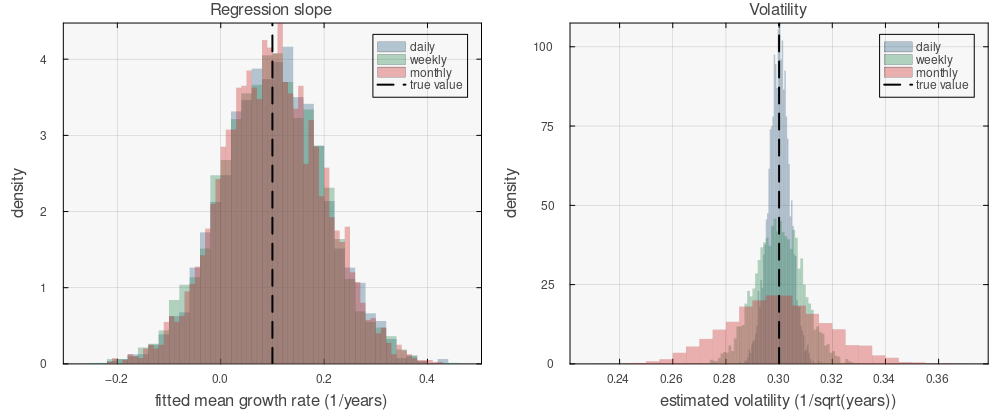

In [6]:
let
    p1 = plot(xlabel = "fitted mean growth rate (1/years)", ylabel = "density",
        title = "Regression slope", titlefontsize = 11, legend = :topright)
    p2 = plot(xlabel = "estimated volatility (1/sqrt(years))", ylabel = "density",
        title = "Volatility", titlefontsize = 11, legend = :topright)
    colors = (daily = :steelblue4, weekly = :seagreen4, monthly = :firebrick3)
    for name ∈ (:daily, :weekly, :monthly)
        res = sampling_results[name]
        histogram!(p1, res.μ̂_g; bins = 60, normalize = :pdf, alpha = 0.35,
            color = colors[name], linewidth = 0, label = String(name))
        histogram!(p2, res.σ_hat; bins = 60, normalize = :pdf, alpha = 0.35,
            color = colors[name], linewidth = 0, label = String(name))
    end
    vline!(p1, [μ_g_true]; color = :black, linestyle = :dash, label = "true value")
    vline!(p2, [σ_true]; color = :black, linestyle = :dash, label = "true value")
    plot(p1, p2; layout = (1, 2), size = (1000, 420),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

___

## Task 2: Calculate the Observation Period Needed for a Chosen Precision

In this task, we use the regression standard error to determine how long we need to observe prices for a chosen precision. First, let's distinguish extending the observation period from collecting more observations within that period.

### Observation period versus sampling frequency

At a fixed $T_{\text{span}}$, sampling more frequently increases $N$. However, the factor $c_N$ approaches $6/5$, giving:

$$
\mathrm{SE}(\hat{\mu}_g)
\longrightarrow \sqrt{\frac{6}{5}}\frac{\sigma}{\sqrt{T_{\text{span}}}}
\qquad\text{as }N\to\infty\text{ with }T_{\text{span}}\text{ fixed}.
$$

Thus, finer sampling does not drive the slope uncertainty to zero. The additional log prices share the same accumulated Brownian changes. Extending the observation period reduces the standard error approximately as $1/\sqrt{T_{\text{span}}}$; for densely sampled prices, halving the standard error requires about four times as many years of data. Volatility behaves differently because its estimate uses the independent one-step growth increments, whose number increases with finer sampling.

> __Comparison with the sample mean:__ Method 1 of the lecture estimates mean growth using $g^\prime=(1/N)\sum_{j=1}^{N}g_j$. The intermediate log prices cancel, giving $g^\prime=\ln(S_{T_{\text{span}}}/S_0)/T_{\text{span}}$ and $\mathrm{SE}(g^\prime)=\sigma/\sqrt{T_{\text{span}}}$. Both methods estimate $\mu_g$, but the least-squares slope uses the price history differently. With dense sampling, its standard error is about 10% larger under the GBM assumptions.

We continue with the regression slope so the uncertainty calculation corresponds to the estimator used in the parameter example.

### Plan for a chosen interval width

With known volatility, a 95% confidence interval for $\mu_g$ is:

$$
\hat{\mu}_g\pm z_{0.975}\,\sigma\sqrt{\frac{c_N}{T_{\text{span}}}},
\qquad z_{0.975}\approx1.96.
$$

Let $h>0$ be the desired half-width, in $\mathrm{yr}^{-1}$. Requiring the interval half-width to be no larger than $h$ gives:

$$
z_{0.975}\,\sigma\sqrt{\frac{c_N}{T_{\text{span}}}}\leq h
\quad\Longrightarrow\quad
T_{\text{span}}\geq c_N\left(\frac{z_{0.975}\sigma}{h}\right)^2.
$$

Because $c_N\leq6/5$, we can use the following sufficient observation period without first choosing the sampling frequency:

$$
\boxed{T_{\text{span}}\geq\frac{6}{5}\left(\frac{z_{0.975}\sigma}{h}\right)^2.}
$$

The right-hand side has units of years. This bound is slightly conservative and closely approximates the required period for dense sampling. We use `σ_true` as the assumed volatility for this planning calculation and tabulate the observation periods for several choices of $h$:

In [7]:
z95 = quantile(Normal(), 0.975)
span_table = let
    df = DataFrame(half_width_per_year = Float64[], sufficient_years = Float64[])
    for h ∈ (0.10, 0.05, 0.02, 0.01)
        push!(df, (h, (6/5)*(z95*σ_true/h)^2))
    end
    df
end
N_daily = sampling_results[:daily].N
model_half_width = z95*regression_slope_se(σ_true, T_span, N_daily)
println("With σ = $(σ_true) and $(T_span) years of daily data, ",
    "the regression 95% half-width is ± $(round(model_half_width, digits = 3)) per year.")
pretty_table(span_table; formatters = [fmt__printf("%.2f", [1,2])])

With σ = 0.3 and 11.0 years of daily data, the regression 95% half-width is ± 0.194 per year.
┌─────────────────────┬──────────────────┐
│ half_width_per_year │ sufficient_years │
│             Float64 │          Float64 │
├─────────────────────┼──────────────────┤
│                0.10 │            41.49 │
│                0.05 │           165.95 │
│                0.02 │          1037.19 │
│                0.01 │          4148.78 │
└─────────────────────┴──────────────────┘


With the default volatility of $0.30\,\mathrm{yr}^{-1/2}$, eleven years of daily observations give a regression interval half-width of about $0.19\,\mathrm{yr}^{-1}$. A half-width of $0.05\,\mathrm{yr}^{-1}$ requires approximately 166 years, while a half-width of $0.01\,\mathrm{yr}^{-1}$ requires more than 4,100 years. These values change with the assumed volatility and desired precision. Such long periods are a consequence of the constant-parameter model; they also show why maintaining the same mean growth rate over the entire required history is a demanding assumption.

We have quantified the uncertainty in the fitted slope. Let's now examine what that uncertainty means for a target-probability calculation.

___

## Task 3: Propagate Regression Uncertainty to the Target Probability

In this task, we use a fitted mean growth rate and volatility to calculate the probability of exceeding a target scaled NPV, then examine how parameter uncertainty affects that result.

### Recall the scheduled-sale probability

Suppose we buy shares and sell them after a holding period $T>0$, measured in years. Let $g_y$ be the constant, continuously compounded benchmark growth rate corresponding to yield $y$, and let $\rho_\star>-1$ be the target scaled NPV. The [lecture's target probability](../../CHEME-5660-L4b-Lecture-SingleAsset-GeometricBrownianMotion-TradeRule-Fall-2026.ipynb) is:

$$
p(\mu_g,\sigma;\rho_\star)
=\mathbb P(\rho_T>\rho_\star)
=1-\Phi\!\left(
\frac{\ln(1+\rho_\star)+(g_y-\mu_g)T}{\sigma\sqrt T}
\right),
$$

where $\Phi$ is the standard normal cumulative distribution function. The holding period $T$ describes the future trade; $T_{\text{span}}$ describes the price history used to estimate the parameters.

### Vary the fitted inputs

We select one simulated daily history from Task 1 using `selected_replicate`. Its regression slope and volatility estimate become `μ_g_hat` and `σ_hat`, the inputs to our probability calculation. This gives us a concrete fitted model whose parameter uncertainty we can examine.

Replacing the true volatility by `σ_hat` gives the estimated standard errors:

$$
\widehat{\mathrm{SE}}(\hat\mu_g)
=\hat\sigma\sqrt{\frac{c_N}{T_{\text{span}}}},
\qquad
\widehat{\mathrm{SE}}(\hat\sigma)
\approx\frac{\hat\sigma}{\sqrt{2(N-1)}}.
$$

We form approximate 95% intervals by adding and subtracting $z_{0.975}$ standard errors from each estimate. The normal interval for the slope is approximate here because we have estimated volatility; the volatility interval also uses a large-sample approximation. The daily sample contains enough increments for these approximations to be useful under the model assumptions.

For each target, we first evaluate the probability at the fitted parameter values. We then vary mean growth over its interval while holding volatility fixed, and vary volatility over its interval while holding mean growth fixed. The two shaded ranges show the separate effects of uncertainty in the fitted inputs. They are sensitivity ranges, not a joint 95% confidence band for the probability.

[The `target_probability(...)` function](docs/target_probability.md) evaluates the closed-form probability. For mean growth, the probability increases with the input, so the lower and upper parameter endpoints also give the lower and upper probabilities. For volatility, the direction depends on the target; the code orders the two resulting probabilities before drawing the shaded range:

Selected daily history 1: fitted μ_g = -0.0269 per year; fitted σ = 0.3033 per sqrt(year).


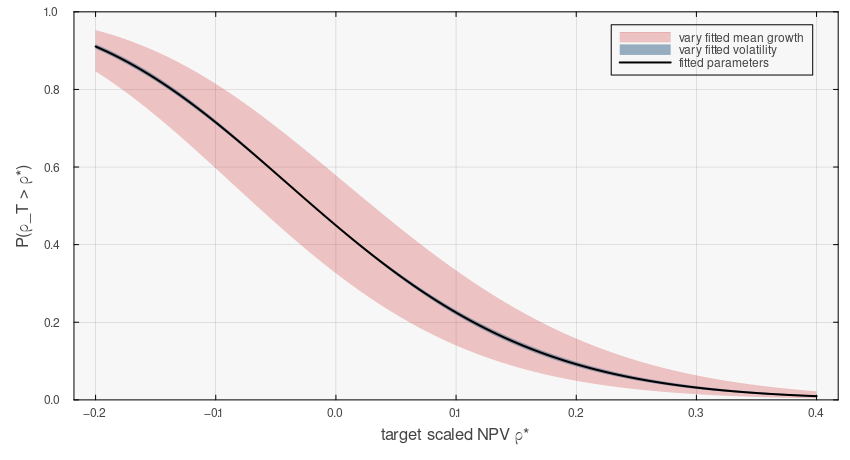

In [8]:
function target_probability(μ_g::Real, σ::Real, T::Real, g_y::Real, ρ_star::Real)
    σ > 0 || throw(ArgumentError("σ must be positive."))
    T > 0 || throw(ArgumentError("T must be positive."))
    ρ_star > -1 || throw(ArgumentError("The target scaled NPV must exceed -1."))
    return ccdf(Normal(), (log1p(ρ_star) + (g_y - μ_g)*T)/(σ*sqrt(T)))
end

selected_replicate = 1                  # choose one of the fitted daily histories from Task 1
μ_g_hat = sampling_results[:daily].μ̂_g[selected_replicate]
σ_hat = sampling_results[:daily].σ_hat[selected_replicate]
T_hold = 63/252                         # scheduled holding period (years): one trading quarter
g_y = 0.05                             # assumed benchmark growth rate (1/years)
se_μ_g = regression_slope_se(σ_hat, T_span, N_daily)
se_σ = σ_hat/sqrt(2*(N_daily - 1))
μ_g_interval = (μ_g_hat - z95*se_μ_g, μ_g_hat + z95*se_μ_g)
σ_interval = (σ_hat - z95*se_σ, σ_hat + z95*se_σ)
if σ_interval[1] <= 0
    throw(ArgumentError("The normal volatility interval reaches zero; use a positive-valued interval."))
end

println("Selected daily history $(selected_replicate): ",
    "fitted μ_g = $(round(μ_g_hat, digits = 4)) per year; ",
    "fitted σ = $(round(σ_hat, digits = 4)) per sqrt(year).")
targets = range(-0.20, 0.40, length = 121)
p_point = [target_probability(μ_g_hat, σ_hat, T_hold, g_y, ρ) for ρ ∈ targets]
p_μ_g_low = [target_probability(μ_g_interval[1], σ_hat, T_hold, g_y, ρ) for ρ ∈ targets]
p_μ_g_high = [target_probability(μ_g_interval[2], σ_hat, T_hold, g_y, ρ) for ρ ∈ targets]
p_σ_at_low = [target_probability(μ_g_hat, σ_interval[1], T_hold, g_y, ρ) for ρ ∈ targets]
p_σ_at_high = [target_probability(μ_g_hat, σ_interval[2], T_hold, g_y, ρ) for ρ ∈ targets]
p_σ_min = min.(p_σ_at_low, p_σ_at_high)
p_σ_max = max.(p_σ_at_low, p_σ_at_high)

let
    plot(targets, p_μ_g_high; fillrange = p_μ_g_low, fillalpha = 0.25, color = :firebrick3, linewidth = 0,
        label = "vary fitted mean growth", xlabel = "target scaled NPV ρ*", ylabel = "P(ρ_T > ρ*)",
        size = (850, 460), legend = :topright, ylims = (0, 1),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
    plot!(targets, p_σ_max; fillrange = p_σ_min, fillalpha = 0.5, color = :steelblue4,
        linewidth = 0, label = "vary fitted volatility")
    plot!(targets, p_point; color = :black, label = "fitted parameters")
end

For the default selected history, the fitted mean growth rate is about $-0.027$ per year and the fitted volatility is about $0.303$ per square root of a year. Although the true mean growth rate is positive, the fitted slope for one history can be negative; the wide sampling distribution in Task 1 explains why.

Let's read off the probabilities at several targets. In `decision_table`, `fitted` uses both fitted parameters, `growth_min` and `growth_max` show the range obtained by varying mean growth, and `vol_min` and `vol_max` show the range obtained by varying volatility. A target of zero corresponds to a positive scaled NPV, meaning the discounted sale proceeds exceed the initial investment:

In [9]:
decision_table = let
    df = DataFrame(target = Float64[], fitted = Float64[], growth_min = Float64[],
        growth_max = Float64[], vol_min = Float64[], vol_max = Float64[])
    for ρ ∈ (-0.10, 0.0, 0.05, 0.10, 0.20)
        p_vol = [target_probability(μ_g_hat, σ, T_hold, g_y, ρ) for σ ∈ σ_interval]
        push!(df, (ρ, target_probability(μ_g_hat, σ_hat, T_hold, g_y, ρ),
            target_probability(μ_g_interval[1], σ_hat, T_hold, g_y, ρ),
            target_probability(μ_g_interval[2], σ_hat, T_hold, g_y, ρ),
            minimum(p_vol), maximum(p_vol)))
    end
    df
end
pretty_table(decision_table; formatters = [fmt__printf("%.3f", [1,2,3,4,5,6])])

┌─────────┬─────────┬────────────┬────────────┬─────────┬─────────┐
│  target │  fitted │ growth_min │ growth_max │ vol_min │ vol_max │
│ Float64 │ Float64 │    Float64 │    Float64 │ Float64 │ Float64 │
├─────────┼─────────┼────────────┼────────────┼─────────┼─────────┤
│  -0.100 │   0.715 │      0.597 │      0.814 │   0.710 │   0.720 │
│   0.000 │   0.450 │      0.326 │      0.578 │   0.448 │   0.451 │
│   0.050 │   0.327 │      0.220 │      0.450 │   0.323 │   0.331 │
│   0.100 │   0.225 │      0.140 │      0.333 │   0.219 │   0.231 │
│   0.200 │   0.092 │      0.049 │      0.157 │   0.086 │   0.098 │
└─────────┴─────────┴────────────┴────────────┴─────────┴─────────┘


For the default selected history, the fitted probability of a positive scaled NPV is about $0.45$. Varying mean growth over its approximate interval changes this probability from about $0.33$ to $0.58$, while varying volatility changes it from about $0.448$ to $0.451$. The range from varying mean growth is much wider for the selected history and targets. Eleven years of daily observations estimate volatility relatively precisely, while leaving considerable uncertainty in the regression slope. The resulting probability should therefore be read together with the uncertainty in its fitted inputs.

The size of either effect also depends on the target and holding period. For example, changing mean growth by $\delta\mu_g$ changes the standardized probability threshold by $-\delta\mu_g\sqrt T/\sigma$. This change grows with the square root of the holding period, but its effect on the probability depends on where the threshold lies on the normal distribution. It does not imply that the probability range must widen for every target as the holding period increases.

These comparisons are conditional on the fitted GBM model and on varying one parameter at a time. Changing the selected history, benchmark, holding period, or target changes the numerical results; departures from constant growth, constant volatility, and independent increments introduce effects beyond the parameter uncertainty considered here.

___

## Summary

We used the same regression estimator as the parameter example and calculated its uncertainty under the GBM assumptions. This connected the fitted mean growth rate to the length of the observed price history and allowed us to examine how parameter uncertainty affects a scheduled-sale probability.

> __Key Takeaways:__
>
> * **Uncertainty in the fitted mean growth rate:** We derived the covariance of the least-squares estimates using the Brownian error covariance. This gave us a standard error for the fitted slope that accounts for dependence between log prices and the increase in their variance over time.
> * **Observation period and sampling frequency:** We used simulations and the regression standard-error formula to compare mean-growth and volatility precision. Finer sampling improved volatility precision but left substantial uncertainty in the fitted mean growth rate; we then calculated how much longer an observation period is needed for a chosen interval width.
> * **Uncertainty in target probabilities:** We used fitted parameters from a simulated price history to calculate the probability of exceeding a target scaled NPV. Varying mean growth and volatility separately showed how uncertainty in those inputs changes the result and why a fitted probability needs to be interpreted with its parameter uncertainty.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

The sampling distributions and uncertainty calculations assume a constant-parameter GBM observed without measurement error. Changes in market conditions, heavy tails, and dependence between growth increments can affect the validity of these calculations.